# Pro player cohorts, part 3: earnings concentration, by title and community

**Purpose**: third notebook in the pro-cohort thread (`pro_player_debut_age_and_tenure.ipynb`
found C1 debuts oldest/has longest careers; `pro_player_roster_churn.ipynb`
found C1 has the lowest roster churn and C0 the highest). This one asks
whether the **concentration of money** among pros follows the same
community pattern as the **concentration of audience attention** already
found on the creator side -- `cross_title_intra_community_comparison.ipynb`
computed a Gini coefficient on each title's per-channel mean viewer count
and found Dota 2 the single most concentrated title in the dataset,
C1 generally top-heavy. Does pro earnings show the same shape, on an
entirely independent signal (money, not attention)? Same scope as parts
1-2: C0/C1/C2, C3 excluded (no player data at all).

**A real confound to check directly, not just note**: `total_earnings`
is lifetime-cumulative. C1 was already found to have the longest average
careers (part 1) -- more career time mechanically gives more *chances*
to accumulate earnings unevenly, so a raw earnings-Gini difference
between communities could partly be a tenure artifact rather than a
real "money is more concentrated in this community's talent pool"
finding. Checked below via a per-active-year normalization, not left as
an unexamined caveat.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from etl.db import get_connection

COMMUNITY_TITLE_LISTS = {
    "C0": ["apex_legends", "fortnite", "league_of_legends", "overwatch", "rainbow_six_siege", "rocket_league", "teamfight_tactics", "valorant"],
    "C1": ["age_of_empires_ii", "counter_strike", "dota2", "hearthstone", "pubg", "starcraft2"],
    "C2": ["brawl_stars", "free_fire", "mobile_legends_bb", "pubg_mobile", "wild_rift"],
    "C3": ["guilty_gear", "mortal_kombat", "street_fighter", "tekken"],
}
community_by_title = {t: c for c, titles in COMMUNITY_TITLE_LISTS.items() for t in titles}
in_scope_titles = [t for t in community_by_title if community_by_title[t] != "C3"]

import yaml
with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config if t.get("is_active")}

colors = {"C0": "#C44E52", "C1": "#4C72B0", "C2": "#55A868"}
order = ["C1", "C0", "C2"]

def gini(x):
    # Identical formula to cross_title_intra_community_comparison.ipynb's
    # own gini() -- same method reused deliberately, not reimplemented
    # differently, so the two Gini series are comparable.
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return np.nan
    cum = np.cumsum(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) - (n + 1) * cum[-1]) / (n * cum[-1])

## Load players, compute Gini on lifetime total_earnings

`total_earnings` is never NULL (checked live: 0 of 51,611 rows) --
0 is a real, meaningful value (15.7% of players), not missing data, so
every player is included, not just ones with recorded earnings.

In [2]:
conn = get_connection()
players = pd.DataFrame(conn.execute(
    "SELECT title_id, liquipedia_page, total_earnings, status FROM players_lpdb"
).fetchall(), columns=["title_id", "liquipedia_page", "total_earnings", "status"])
conn.close()

players = players[players["title_id"].isin(in_scope_titles)]
players["community"] = players["title_id"].map(community_by_title)

rows = []
for title_id, g in players.groupby("title_id"):
    rows.append({
        "title_id": title_id, "title": display_name_by_id[title_id], "community": community_by_title[title_id],
        "n_players": len(g), "earnings_gini": gini(g["total_earnings"].values),
        "pct_zero_earnings": (g["total_earnings"] == 0).mean() * 100,
        "total_pool": g["total_earnings"].sum(),
    })
earnings_df = pd.DataFrame(rows).sort_values(["community", "earnings_gini"], ascending=[True, False])
print(f"Titles covered: {len(earnings_df)} of 17 in-scope (missing: {sorted(set(in_scope_titles) - set(earnings_df['title_id']))})")
earnings_df.round(3)

Titles covered: 17 of 17 in-scope (missing: ['age_of_empires_ii', 'brawl_stars'])


,title_id,title,community,n_players,earnings_gini,pct_zero_earnings,total_pool
12,rocket_league,Rocket League,C0,3563,0.888,22.621,57432350.0
11,rainbow_six_siege,Rainbow Six Siege,C0,3510,0.887,25.470,67987863.0
6,league_of_legends,League of Legends,C0,5974,0.874,22.112,125028390.0
0,apex_legends,Apex Legends,C0,2407,0.873,15.953,39540984.0
8,overwatch,Overwatch,C0,4202,0.836,18.015,56318386.0
15,valorant,VALORANT,C0,5604,0.822,21.413,53019999.0
14,teamfight_tactics,Teamfight Tactics,C0,1221,0.818,15.479,20452683.0
3,fortnite,Fortnite,C0,5740,0.746,0.784,222544420.0
13,starcraft2,StarCraft II,C1,2098,0.915,14.538,44521032.0
2,dota2,Dota 2,C1,1841,0.879,15.807,401425796.0


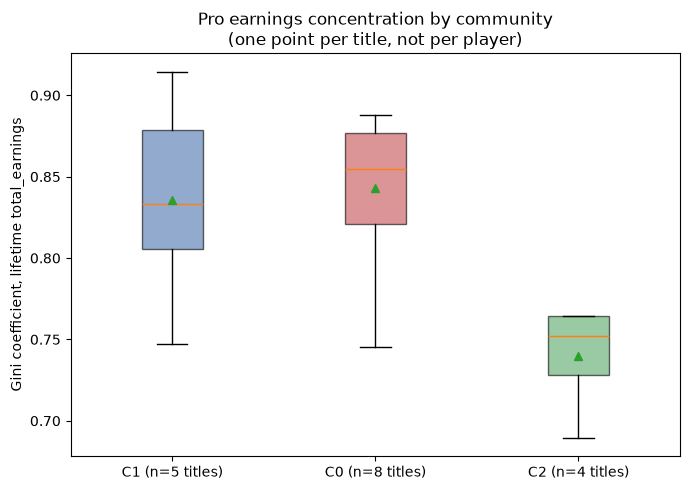

,count,mean,std,min,25%,50%,75%,max
community,,,,,,,,
C0,8.0,0.843,0.048,0.746,0.821,0.854,0.877,0.888
C1,5.0,0.836,0.065,0.747,0.806,0.833,0.879,0.915
C2,4.0,0.740,0.035,0.690,0.728,0.752,0.764,0.765


In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
data = [earnings_df[earnings_df["community"] == c]["earnings_gini"] for c in order]
bp = ax.boxplot(data, tick_labels=[f"{c} (n={len(d)} titles)" for c, d in zip(order, data)], patch_artist=True, showmeans=True)
for patch, c in zip(bp["boxes"], order):
    patch.set_facecolor(colors[c])
    patch.set_alpha(0.6)
ax.set_ylabel("Gini coefficient, lifetime total_earnings")
ax.set_title("Pro earnings concentration by community\n(one point per title, not per player)")
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_earnings_fig1_by_community.png", dpi=150, bbox_inches="tight")
plt.show()

earnings_df.groupby("community")["earnings_gini"].describe().round(3)

## Cross-check against the creator-side (audience-attention) Gini

Reference values copied directly from `cross_title_intra_community_comparison.ipynb`'s
own already-computed, already-published per-title table (same `gini()`
formula, reused above) -- not recomputed from `viewership_snapshots`
here, to keep this notebook's job strictly "compare against," not
"re-derive."

17 titles with both figures
Spearman rho (earnings_gini vs audience_gini, across titles): 0.235 (p=0.365)


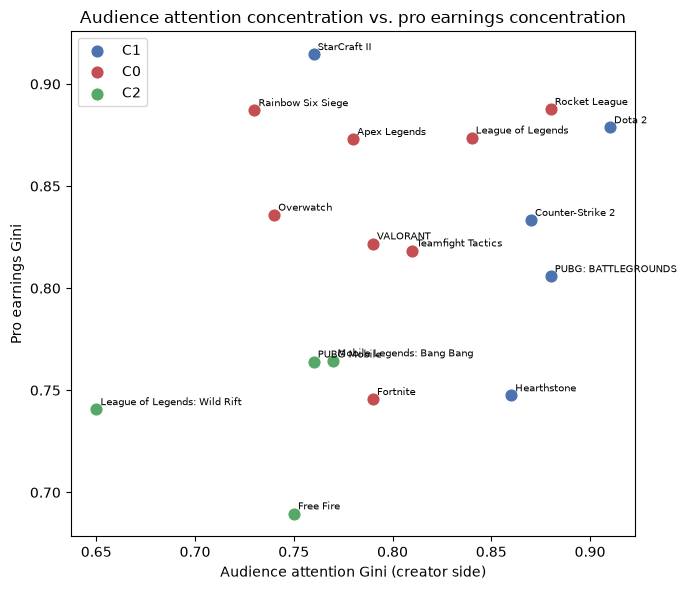

In [4]:
AUDIENCE_GINI = {
    "apex_legends": 0.78, "teamfight_tactics": 0.81, "fortnite": 0.79, "rocket_league": 0.88,
    "league_of_legends": 0.84, "rainbow_six_siege": 0.73, "valorant": 0.79, "overwatch": 0.74,
    "age_of_empires_ii": 0.82, "counter_strike": 0.87, "dota2": 0.91, "starcraft2": 0.76,
    "hearthstone": 0.86, "pubg": 0.88, "wild_rift": 0.65, "mobile_legends_bb": 0.77,
    "free_fire": 0.75, "brawl_stars": 0.75, "pubg_mobile": 0.76,
}

earnings_df["audience_gini"] = earnings_df["title_id"].map(AUDIENCE_GINI)
compare = earnings_df.dropna(subset=["audience_gini"])
print(f"{len(compare)} titles with both figures")

rho, p = spearmanr(compare["earnings_gini"], compare["audience_gini"])
print(f"Spearman rho (earnings_gini vs audience_gini, across titles): {rho:.3f} (p={p:.3f})")

fig, ax = plt.subplots(figsize=(7, 6))
for c in order:
    sub = compare[compare["community"] == c]
    ax.scatter(sub["audience_gini"], sub["earnings_gini"], color=colors[c], label=c, s=60)
    for _, r in sub.iterrows():
        ax.annotate(r["title"], (r["audience_gini"], r["earnings_gini"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Audience attention Gini (creator side)")
ax.set_ylabel("Pro earnings Gini")
ax.set_title("Audience attention concentration vs. pro earnings concentration")
ax.legend()
plt.tight_layout()
plt.savefig(Path.cwd() / "_pro_earnings_fig2_vs_audience.png", dpi=150, bbox_inches="tight")
plt.show()

## Robustness check: does the tenure confound explain the community pattern?

Normalize each player's earnings by their known tenure (years since
first roster join, from `squadplayers_lpdb`, same join logic as parts
1-2) and re-run Gini on earnings-per-active-year instead of lifetime
total. If the community-level pattern above is mostly a tenure artifact,
it should weaken substantially here.

In [5]:
conn = get_connection()
sp = pd.DataFrame(conn.execute(
    "SELECT title_id, player_link, join_date FROM squadplayers_lpdb WHERE join_date IS NOT NULL"
).fetchall(), columns=["title_id", "player_link", "join_date"])
conn.close()
sp["join_date"] = pd.to_datetime(sp["join_date"], errors="coerce")
sp = sp[(sp["join_date"] >= "1998-01-01") & (sp["title_id"].isin(in_scope_titles))]
first_join = sp.groupby(["title_id", "player_link"])["join_date"].min().rename("first_join_date").reset_index()
first_join["years_tracked"] = (pd.Timestamp("2026-10-02") - first_join["first_join_date"]).dt.days / 365.25
first_join["years_tracked"] = first_join["years_tracked"].clip(lower=0.5)  # floor against a same-day debut dividing by ~0

merged = players.merge(first_join.rename(columns={"player_link": "liquipedia_page"}), on=["title_id", "liquipedia_page"], how="inner")
merged["earnings_per_year"] = merged["total_earnings"] / merged["years_tracked"]
print(f"{len(merged):,} of {len(players):,} players matched to a known first-join date ({len(merged)/len(players)*100:.1f}%)")

rows = []
for title_id, g in merged.groupby("title_id"):
    if len(g) < 20:
        continue
    rows.append({"title_id": title_id, "community": community_by_title[title_id], "n": len(g), "earnings_per_year_gini": gini(g["earnings_per_year"].values)})
per_year_df = pd.DataFrame(rows)
per_year_df.groupby("community")["earnings_per_year_gini"].describe().round(3)

39,020 of 51,611 players matched to a known first-join date (75.6%)


,count,mean,std,min,25%,50%,75%,max
community,,,,,,,,
C0,8.0,0.799,0.052,0.696,0.770,0.814,0.839,0.847
C1,5.0,0.815,0.057,0.751,0.774,0.801,0.871,0.878
C2,4.0,0.685,0.040,0.625,0.679,0.702,0.708,0.711


### Read -- C0 and C1 are both highly concentrated and nearly tied; the audience cross-check comes back null; the tenure confound doesn't explain any of it

**C0 and C1 are statistically indistinguishable on earnings concentration
-- both high, not one clearly above the other.** Mean Gini: C0 0.843,
C1 0.836, both well above C2's 0.740. Unlike the debut-age/career-length/
churn findings so far, **this is not a result that cleanly separates C0
from C1** -- both communities run winner-take-all pro economies; **C2
(mobile) is the one that stands apart, with meaningfully more evenly
spread earnings.** StarCraft II (0.915) is the single most earnings-
concentrated title in the dataset, not Dota 2 (0.879, still high) --
worth noting since Dota 2 was the audience-side concentration leader
(`cross_title_intra_community_comparison.ipynb`'s 0.91 audience Gini) and
doesn't hold that title here.

**The cross-check against audience-attention concentration comes back
genuinely null: Spearman rho=0.235, p=0.365 across all 17 covered
titles.** A title's audience being concentrated onto a few huge channels
does not predict its pro scene's earnings being similarly concentrated
onto a few huge earners -- these are two independent kinds of
concentration, not two readings of the same underlying "how top-heavy is
this title" property. Worth stating plainly as a real negative result,
not a failed check to gloss over: it means the "concentration" axis
used throughout this project's creator-side work doesn't automatically
transfer to the competitive-earnings side, and the two should keep being
measured and reported separately.

**The tenure confound raised in the intro does not explain the
community pattern -- it survives normalization essentially unchanged.**
Earnings-per-active-year Gini: C0 0.799, C1 0.815, C2 0.685 -- the same
ordering (C0 approx C1, both above C2), similar magnitude, as the raw
lifetime figures. If C1's longer average careers (part 1) were the real
driver of its high earnings-Gini, normalizing by tenure should have
narrowed the gap to C2 substantially; it didn't. This is a real,
tenure-independent concentration difference between the mobile community
and the other two, not an artifact of how long players in each community
have had to accumulate winnings.

## Caveats

- **C3 excluded entirely, C2 still missing Brawl Stars, C1 still missing
  Age of Empires II** -- same gaps as parts 1-2, not yet resolved by the
  LPDB sync as of this run.
- **`total_earnings` is prize money only, not salary/streaming income** --
  for titles with a strong salaried-league structure (franchised leagues
  especially), this systematically understates total pro income and in
  a way that could differ by community if franchising rates differ by
  community (C0 has 2 of this project's 2 tracked franchised-league
  titles). Not correctable with data this project currently has.
- **The earnings-per-year normalization uses `years_tracked` (now minus
  first join), not actual *active* years** -- a player who went fully
  inactive for several years then returned would have their dormant
  years counted as tenure, diluting their per-year figure. A more
  precise version would use the career-length figure from part 1
  directly; this one is a reasonable approximation, not the final word.
- **The audience-Gini reference values are a point-in-time snapshot from
  a different notebook's own run** -- not re-verified live here, cited
  as-is.